In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


## **Supress the warnings**

In [5]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# **Loading the dataset**

In [7]:
train = pd.read_csv("/kaggle/input/titanic/train.csv")
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
test = pd.read_csv("/kaggle/input/titanic/test.csv")
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [9]:
sample = pd.read_csv("/kaggle/input/titanic/gender_submission.csv")
sample.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [11]:
train.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<div style="background-color:#1f77b4; color:white; padding:15px; border-radius:8px; font-family:Arial; line-height:1.6;">
  <h2 style="margin-top:0; font-weight:bold;">Insights on DataFrame Structure:</h2>
  <ol>
    <li><span style="font-weight:bold;text-decoration:underline;">Missing Values:</span><br><br>
       <span style="font-weight:bold;">Age:</span> 714 non-null entries out of 891, indicating a few age entries are missing.<br>
       <span style="font-weight:bold;">Cabin:</span> 204 non-null entries, suggesting a larger number of missing values for cabin.<br>
       <span style="font-weight:bold;">Embarked:</span> 889 non-null entries, showing very less missing values for the Embarked.<br><br>
    </li>
    <li><span style="font-weight:bold; text-decoration:underline;">Data Types:</span><br><br>
       <span style="font-weight:bold;">Categorical Columns (10):</span> Includes columns like Survived,Name,Sex,Ticket,Cabin and Embarked which may need encoding for modeling.<br>
       <span style="font-weight:bold;">Numeric Columns (6):</span> Includes PassengerId, Survived, Pclass, Age, SibSp,Parch and Fare which can be used directly in quantitative analysis.
    </li><br><br>
    <li><span style="font-weight:bold; text-decoration:underline;">Memory Usage:</span><br><br>
       The DataFrame uses approximately 87.3+ KB of memory, which is quite low.
    </li><br><br>
    <li><span style="font-weight:bold; text-decoration:underline;">Column-Specific Observations:</span><br><br>
       <span style="font-weight:bold;">cabin</span> and <span style="font-weight:bold;">age</span> have substantial missing data, which could impact analyses related to effective result.<br>
       <span style="font-weight:bold;">PassengerId, Survived, PClass, Name, Sex, SibSp, Fare and Ticket</span> are fully populated, making them reliable for numeric analysis.
    </li>
  </ol>
</div>


In [12]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


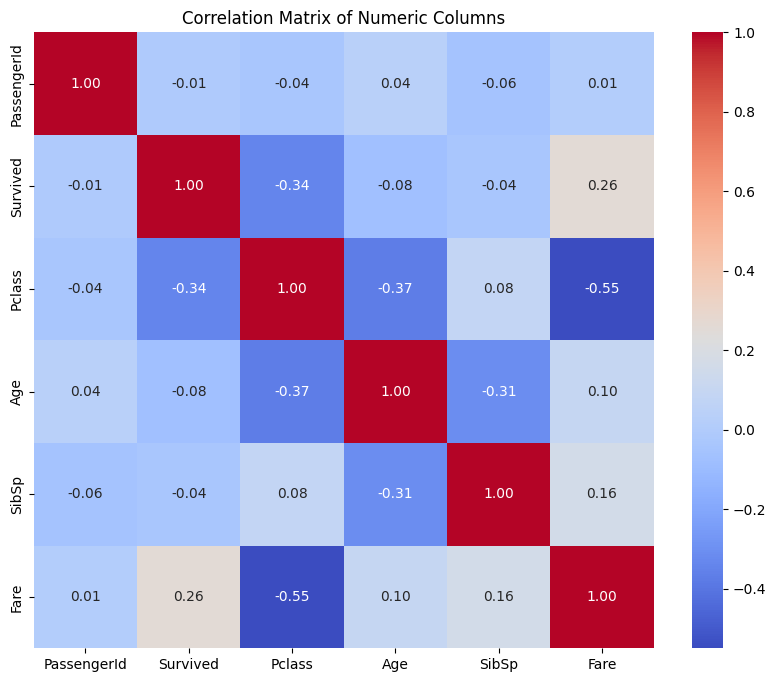

In [13]:
numeric_columns = ["PassengerId", "Survived", "Pclass", "Age", "SibSp", "Fare"]

correlation_matrix = train[numeric_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numeric Columns")
plt.show()

<div style="background-color:#1f77b4; color:white; padding:15px; border-radius:8px; font-family:Arial; line-height:1.6;">
  <h2 style="margin-top:0; font-weight:bold;">Correlation Matrix Insights:</h2>
  <ol>
    <li><span style="font-weight:bold; text-decoration:underline;">Survival's Strongest Links</span><br><br>
       The <span style="font-weight:bold;">Survived</span> row is your most important guide for EDA. It tells which features "explain" survival the best.<br><br>
       <span style="font-weight:bold;">Pclass (-0.34):</span> This is the strongest negative correlation with survival. It confirms that as the class number increases (from 1st to 3rd), the chance of survival drops significantly.<br><br>
       <span style="font-weight:bold;">Fare (0.26):</span> A positive correlation. Higher fares (associated with 1st class) are linked to higher survival rates.<br><br>
       <span style="font-weight:bold;">Age (-0.08):</span> Interestingly, the linear correlation between Age and Survival is very weak. This suggests that the relationship might be non-linear (e.g., both the very young and the very old survived, but middle-aged people didn't), which is why your Title-based imputation was such a smart move—it captures these life stages better than a simple linear trend.
    </li><br><br>
    <li><span style="font-weight:bold; text-decoration:underline;">The "Age" Imputation Insight</span><br><br>
       The <span style="font-weight:bold;">Age vs. Pclass (-0.37):</span> This is a moderate negative correlation. It proves that passengers in higher classes (1st class) were generally older than those in 3rd class.<br><br>
       <span style="font-weight:bold;">Age vs. SibSp (-0.31)</span> There is a negative relationship here as well. Passengers traveling with many siblings or a spouse tended to be younger (likely children in large families).<br><br>
    </li>
  </ol>
</div>


In [14]:
train['Survived']

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

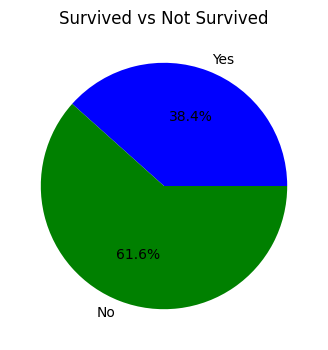

In [15]:
survived = train['Survived'].sum()
not_survived = len(train) - survived
labels = ['Yes', 'No']
counts = [survived, not_survived]

plt.figure(figsize=(6, 4))
plt.pie(counts, labels=labels, colors=['blue', 'green'], autopct='%1.1f%%')
plt.title('Survived vs Not Survived')
plt.show()

<div style="background-color:#1f77b4; color:white; padding:15px; border-radius:8px; font-family:Arial; line-height:1.6;">
<h2 style="margin-top:0; font-weight:bold;">Target Variable (Survived) EDA Insights:</h2>
<ol>
<li><span style="font-weight:bold; text-decoration:underline;">Class Distribution & Imbalance</span>




The <span style="font-weight:bold;">Survival Rate</span> is the core of your project. Your pie chart shows a significant split in outcomes.




<span style="font-weight:bold;">Non-Survivors (61.6%):</span> This is the majority class. If you built a "dumb" model that simply predicted everyone died, it would be 61.6% accurate but useless for finding survivors.




<span style="font-weight:bold;">Survivors (38.4%):</span> This is the minority class. Because of this 62/38 split, you must use metrics like F1-Score or ROC-AUC instead of Accuracy to ensure your model actually learns to identify these individuals.
</li>




<li><span style="font-weight:bold; text-decoration:underline;">Socio-Economic Survival Drivers</span>




The correlation matrix highlights that survival was not random; it was heavily tied to status and wealth.




<span style="font-weight:bold;">Pclass (-0.34):</span> There is a strong negative correlation. As the class number increases (from 1st to 3rd), the likelihood of being in the "Survived" slice of your pie chart drops significantly.




<span style="font-style:italic;">Note:</span> This aligns with the "Women and Children First" protocol, where higher-class passengers often had quicker access to lifeboats.
</li>




<li><span style="font-weight:bold; text-decoration:underline;">Financial & Family Influence</span>




<span style="font-weight:bold;">Fare (0.26):</span> A positive correlation confirms that higher spending on tickets directly correlates with a better chance of survival.




<span style="font-weight:bold;">SibSp (-0.04):</span> This very low correlation suggests that traveling with siblings or a spouse, on its own, did not have a strong linear impact on whether a passenger survived or not.
</li>
</ol>
</div>

In [16]:
train.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [17]:
import math

In [18]:
def plot_boxplots(df, columns, cols=3, figsize=(18, 4)):

    df_plot = df.copy() 
    
    num_plots = len(columns)
    rows = math.ceil(num_plots / cols)


    fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(figsize[0], figsize[1] * rows))
    

    if num_plots == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()

    for i, column in enumerate(columns):
        if column in df_plot.columns and pd.api.types.is_numeric_dtype(df_plot[column]):
            # Use .dropna() to handle missing values, as boxplot requires clean input
            data_to_plot = df_plot[column].dropna()
            
            # Skip plotting if no data remains after dropping NaNs
            if not data_to_plot.empty:
                axes[i].boxplot(data_to_plot, vert=False, patch_artist=True)
                axes[i].set_title(f"Box Plot for {column.capitalize()}")
                axes[i].set_xlabel(column.capitalize())
            else:
                axes[i].axis('off')
                axes[i].set_title(f"{column.capitalize()} (No data to plot)")
        else:
            axes[i].axis('off')
            axes[i].set_title(f"{column.capitalize()} (Not found or not numeric)")


    # Hide unused subplots
    for j in range(num_plots, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

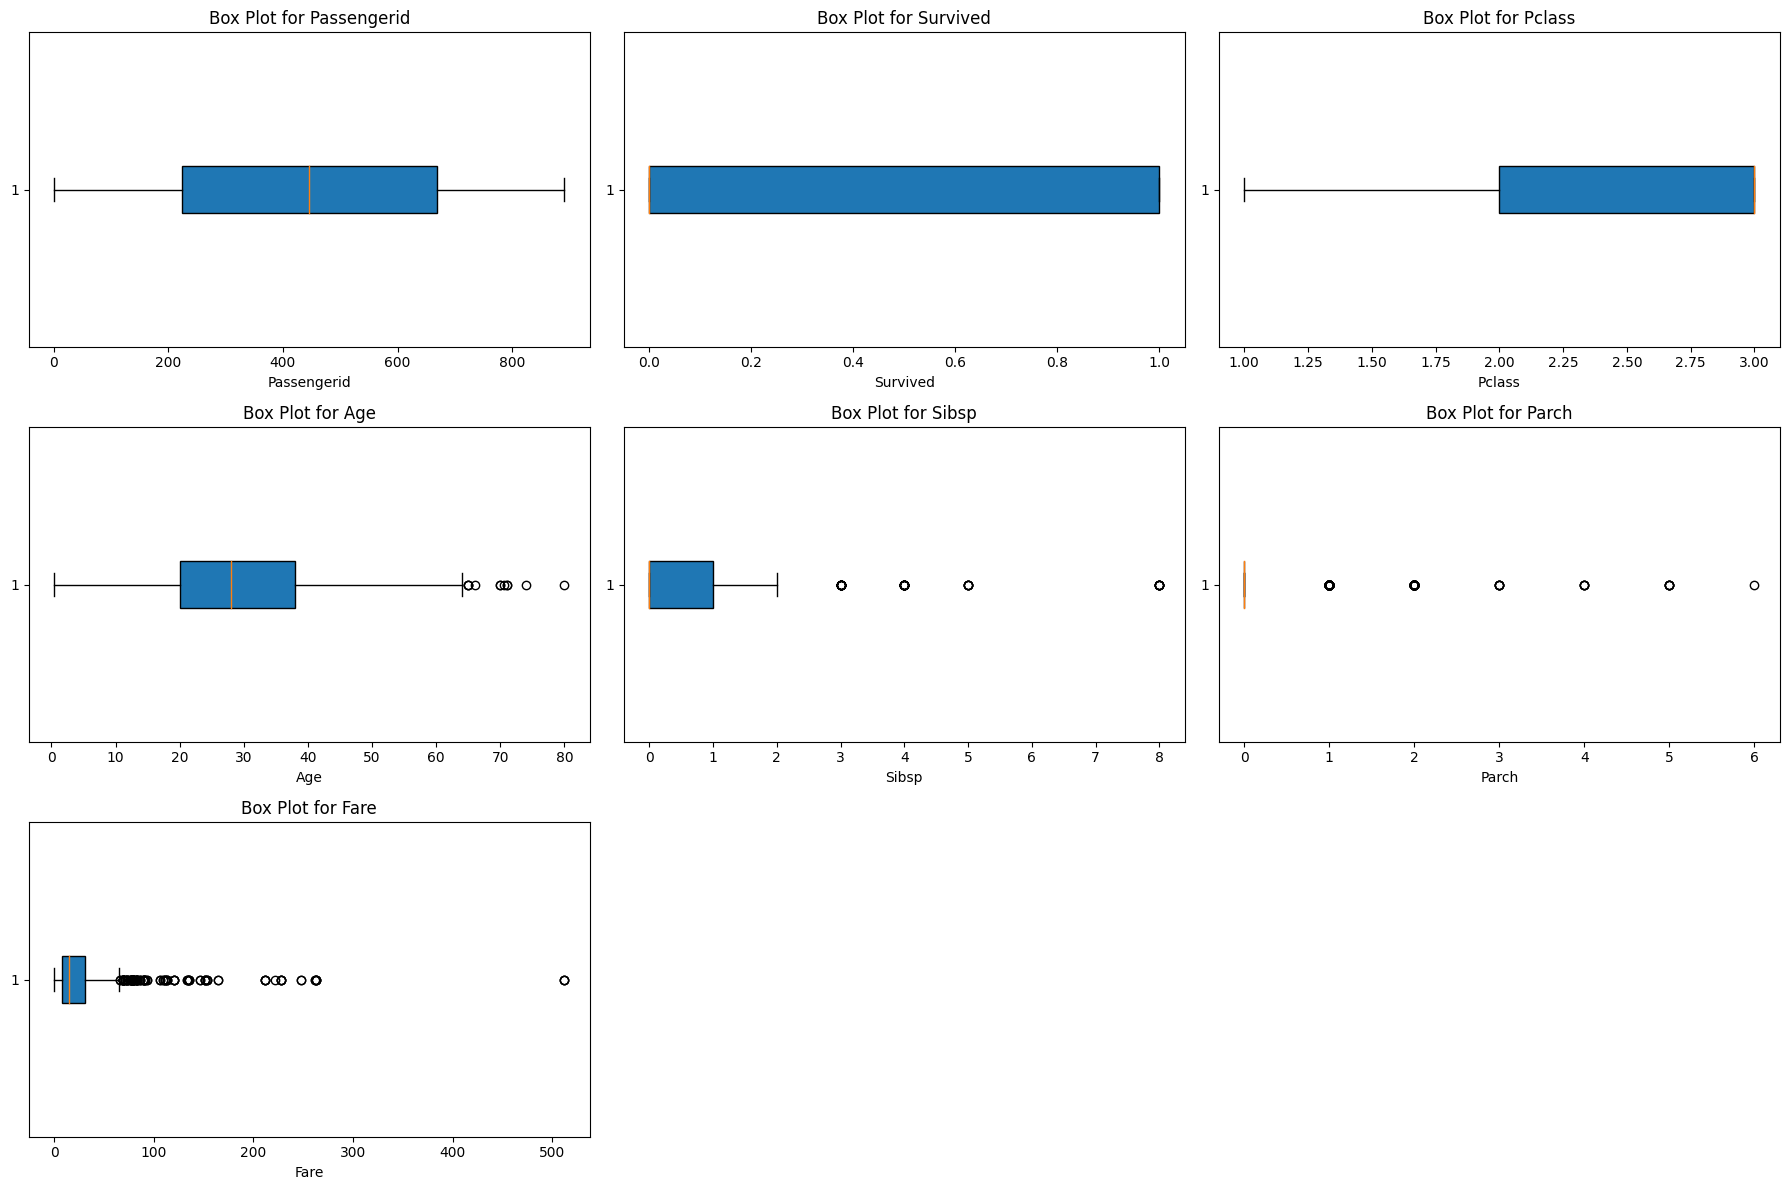

In [19]:
numeric_columns = ["PassengerId", "Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
plot_boxplots(train, numeric_columns)

<div style="background-color:#1f77b4; color:white; padding:15px; border-radius:8px; font-family:Arial; line-height:1.6;">
<h2 style="margin-top:0; font-weight:bold;">Box Plot Outlier & Distribution Insights(For Numerical Columns):</h2>
<ol>
<li><span style="font-weight:bold; text-decoration:underline;">Fare & Economic Extremes</span>




The <span style="font-weight:bold;">Fare</span> box plot shows the most extreme outlier profile in the dataset.




<span style="font-weight:bold;">High-Value Outliers:</span> There is a significant cluster of outliers above 100, stretching all the way to a single point at 512. This confirms that while most passengers paid low fares, a tiny elite group paid substantially more, correlating with the 26% survival link we saw earlier.
</li>




<li><span style="font-weight:bold; text-decoration:underline;">Age Distribution & Life Stages</span>




The <span style="font-weight:bold;">Age</span> box plot reveals a relatively balanced interquartile range (IQR) but contains several outliers at the upper end.




<span style="font-weight:bold;">Elderly Outliers:</span> Several passengers aged 65 to 80 are marked as outliers. These represent the "Old" life stage that your Title-based imputation helps differentiate from the middle-aged majority.
</li>




<li><span style="font-weight:bold; text-decoration:underline;">Family Size & Composition (SibSp/Parch)</span>




Both family-related features exhibit heavily skewed distributions with numerous outliers.




<span style="font-weight:bold;">SibSp Outliers:</span> While most passengers traveled alone or with one person, there are extreme outliers at 3, 4, 5, and 8. These represent the large families that were often traveling in 3rd class.




<span style="font-weight:bold;">Parch Outliers:</span> Similar to SibSp, the Parch (Parents/Children) plot shows that traveling with more than 1-2 family members was statistically rare, with outliers reaching up to 6.
</li>
</ol>
</div>

# **Capping the outliers**

In [20]:
def cap_outliers_iqr(df, columns):
    df_capped = df.copy()

    for column in columns:
        # Only process if the column is numeric and not empty
        if pd.api.types.is_numeric_dtype(df_capped[column]):
            # Calculate quantiles and IQR based on the original data for that column
            Q1 = df_capped[column].quantile(0.25)
            Q3 = df_capped[column].quantile(0.75)
            
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Apply the capping logic directly to the column in the copy
            df_capped[column] = df_capped[column].apply(
                lambda x: lower_bound if x < lower_bound 
                else upper_bound if x > upper_bound else x
            )
            print(f"Capped outliers in column: {column}")
        else:
             print(f"Skipping non-numeric column: {column}")

    # CRITICAL FIX: Return the DataFrame only after the loop has finished
    return df_capped

Capped outliers in column: PassengerId
Capped outliers in column: Survived
Capped outliers in column: Pclass
Capped outliers in column: Age
Capped outliers in column: SibSp
Capped outliers in column: Parch
Capped outliers in column: Fare

--- Data After Capping ---


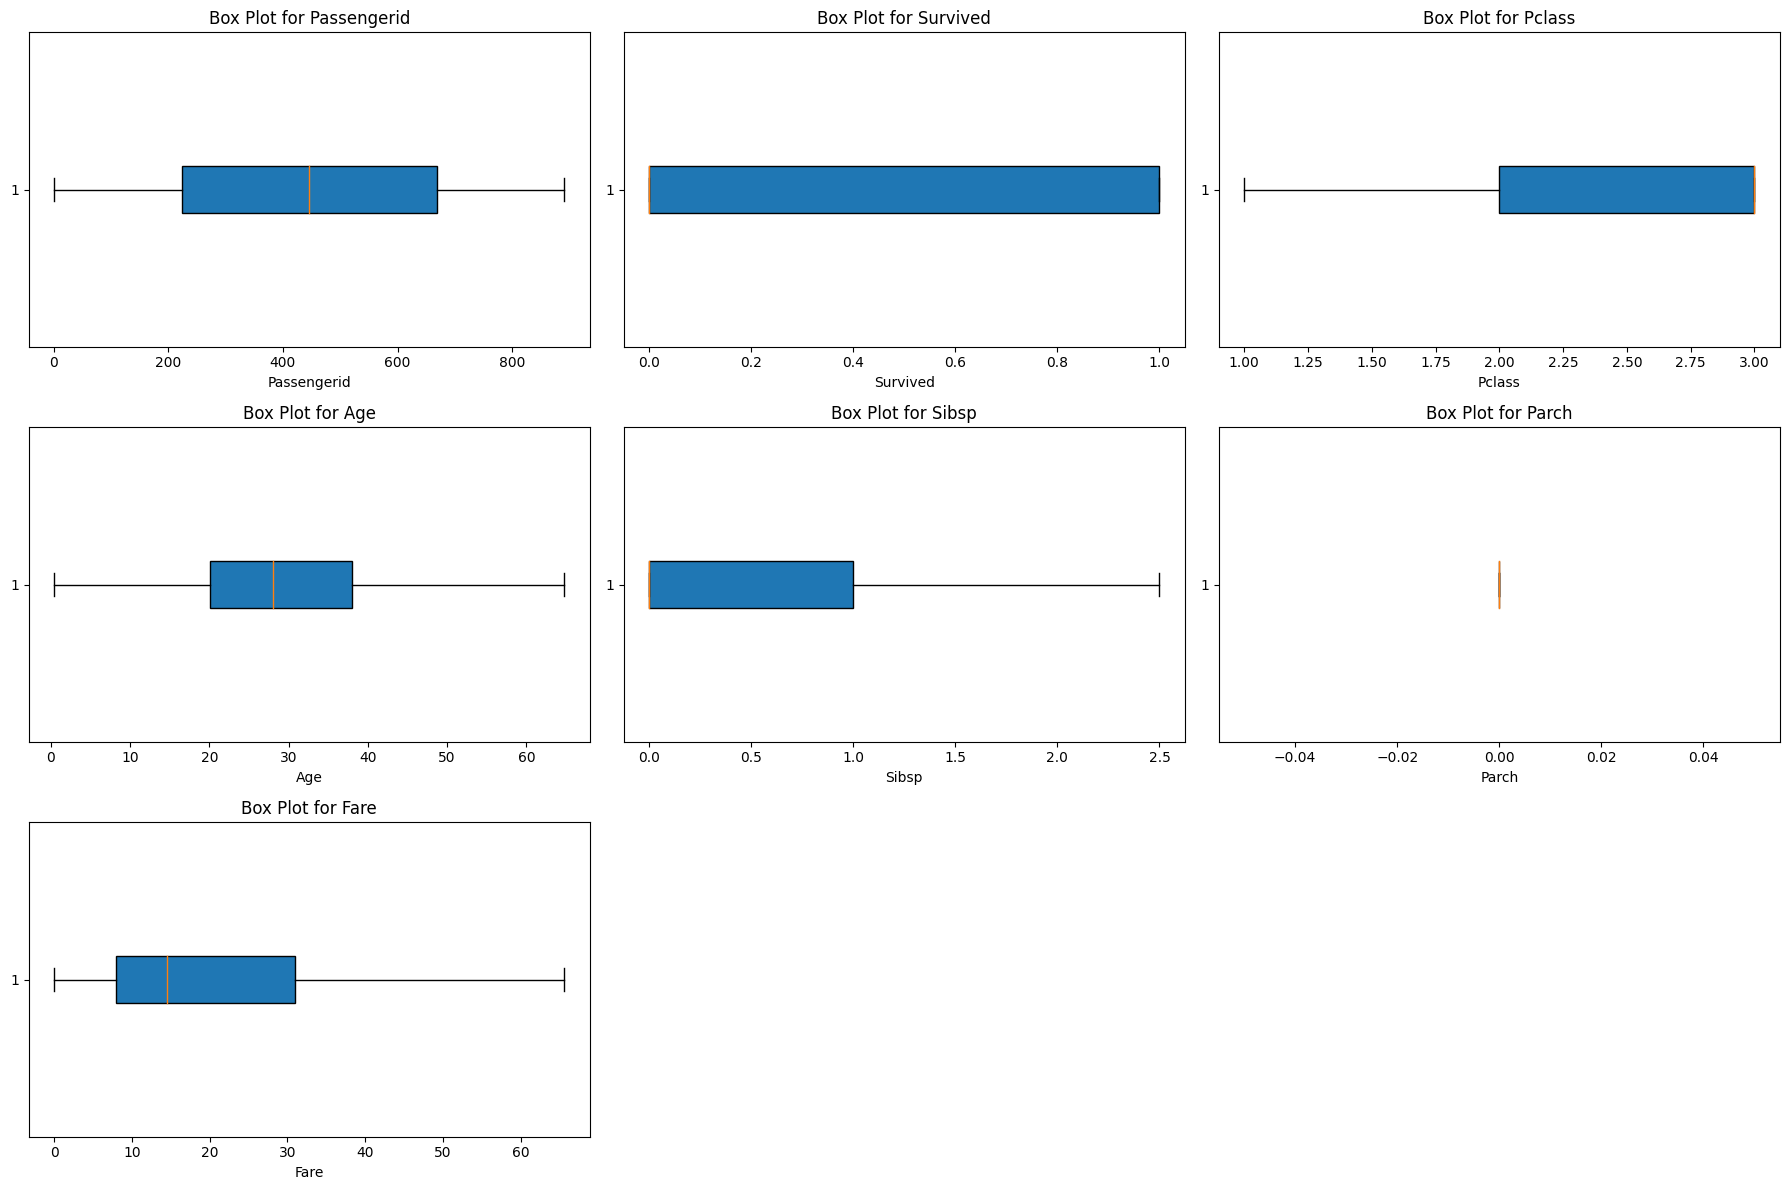

In [21]:
train_capped = cap_outliers_iqr(train, numeric_columns)

print("\n--- Data After Capping ---")
plot_boxplots(train_capped, numeric_columns)

In [22]:
train_capped.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [23]:
train_capped.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [24]:
train_capped.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.0,891.000000
mean,446.000000,0.383838,2.308642,29.622700,0.426487,0.0,24.046813
std,257.353842,0.486592,0.836071,14.316665,0.708246,0.0,20.481625
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.0,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.0,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.0,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.0,31.000000
max,891.000000,1.000000,3.000000,64.812500,2.500000,0.0,65.634400


In [25]:
train_capped["Age"].unique()

array([22.    , 38.    , 26.    , 35.    ,     nan, 54.    ,  2.    ,
       27.    , 14.    ,  4.    , 58.    , 20.    , 39.    , 55.    ,
       31.    , 34.    , 15.    , 28.    ,  8.    , 19.    , 40.    ,
       64.8125, 42.    , 21.    , 18.    ,  3.    ,  7.    , 49.    ,
       29.    , 28.5   ,  5.    , 11.    , 45.    , 17.    , 32.    ,
       16.    , 25.    ,  0.83  , 30.    , 33.    , 23.    , 24.    ,
       46.    , 59.    , 37.    , 47.    , 14.5   , 32.5   , 12.    ,
        9.    , 36.5   , 51.    , 55.5   , 40.5   , 44.    ,  1.    ,
       61.    , 56.    , 50.    , 36.    , 45.5   , 20.5   , 62.    ,
       41.    , 52.    , 63.    , 23.5   ,  0.92  , 43.    , 60.    ,
       10.    , 64.    , 13.    , 48.    ,  0.75  , 53.    , 57.    ,
       24.5   ,  6.    ,  0.67  , 30.5   ,  0.42  , 34.5   ])

In [26]:
train_capped["Cabin"].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [27]:
train_capped["Embarked"].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [28]:
train_capped.describe(include=['object'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,1601,B96 B98,S
freq,1,577,7,4,644


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure we are working with the winning Title-based imputed Age
# Defining a helper function to repeat your logic efficiently
def get_bivariate_analysis(df, column, is_continuous=False, bins=None, labels=None):
    temp_df = df.copy()
    
    # Handle Continuous data by Binning
    if is_continuous and bins:
        col_name = f'{column}_bin'
        temp_df[col_name] = pd.cut(temp_df[column], bins=bins, labels=labels, right=False)
        target_col = col_name
    else:
        target_col = column

    # Grouping logic
    grouped = temp_df.groupby([target_col, 'Survived']).size().unstack(fill_value=0)
    grouped.columns = ['No', 'Yes']
    grouped['Survival %'] = (grouped['Yes'] / (grouped['Yes'] + grouped['No'])) * 100
    grouped = grouped.reset_index()

    # Plotting
    grouped[['No', 'Yes']].set_index(grouped[target_col]).plot(kind='bar', stacked=False, figsize=(10, 5))
    plt.title(f'Survival by {target_col}')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

    # Styling
    return grouped.style.format({'Survival %': '{:.2f}%'}).background_gradient(subset=['Survival %'], cmap='YlGn')


# **Imputation**

## **Age**

In [30]:
train_capped["Age"].value_counts()

Age
24.00    30
22.00    27
18.00    26
28.00    25
19.00    25
         ..
20.50     1
23.50     1
0.92      1
0.42      1
34.50     1
Name: count, Length: 82, dtype: int64

In [31]:
train_capped.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [32]:
def get_title(name):
    """Extracts the title from a passenger's name."""
    title_search = name.split(', ')[1].split('.')[0].strip()
    return title_search

# 2. Apply the function to create the Title column
train_capped['Title'] = train_capped['Name'].apply(get_title)

# 3. Define the mapping to group rare titles
title_mapping = {
    "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",
    "Capt": "Officer", "Col": "Officer", "Major": "Officer",
    "Dr": "Officer", "Rev": "Officer",
    "Countess": "Royal", "Lady": "Royal", "Sir": "Royal",
    "Don": "Royal", "Jonkheer": "Royal", "Dona": "Royal"
}
train_capped['Title'] = train_capped['Title'].replace(title_mapping)

# 4. PERFORM THE IMPUTATION
# We use 'transform' to fill NaNs with the median Age of that specific Title AND Pclass
train_capped['Age'] = train_capped['Age'].fillna(
    train_capped.groupby(['Title', 'Pclass'])['Age'].transform('median')
)

# 5. Final safety check 
# If a specific Title/Pclass combination has NO age data at all, use the global median
train_capped['Age'] = train_capped['Age'].fillna(train_capped['Age'].median())

# 6. Check if any missing values remain in Age
print(f"Missing values in Age: {train_capped['Age'].isnull().sum()}")

Missing values in Age: 0


In [33]:
train_capped.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Title            0
dtype: int64

In [34]:
train_capped.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,65.6344,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,NaN,S,Mr


## **Cabin**

In [35]:
# 1. Extract the Deck first (handles known cabins like 'C123' -> 'C')
train_capped['Deck'] = train_capped['Cabin'].str[0]

# 2. Fill the missing Decks with 'U' (for Unknown) or 'Z'
# 'U' is often more intuitive in reports, but 'Z' works perfectly too!
train_capped['Deck'].fillna('Z', inplace=True)

# 3. Drop the original Cabin column as planned
train_capped.drop('Cabin', axis=1, inplace=True)

# 4. Verify the new distribution
print(train_capped['Deck'].value_counts())

Deck
Z    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64


In [36]:
train_capped.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
Title          0
Deck           0
dtype: int64

## **Embarked**

In [37]:
# Southampton ('S') is the most common port
train_mode = train_capped['Embarked'].mode()[0]
train_capped['Embarked'].fillna(train_mode, inplace=True)

print(f"Missing values in Embarked: {train_capped['Embarked'].isnull().sum()}")

Missing values in Embarked: 0


In [38]:
train_capped.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Title          0
Deck           0
dtype: int64

# **Sex vs. Survival Rate**


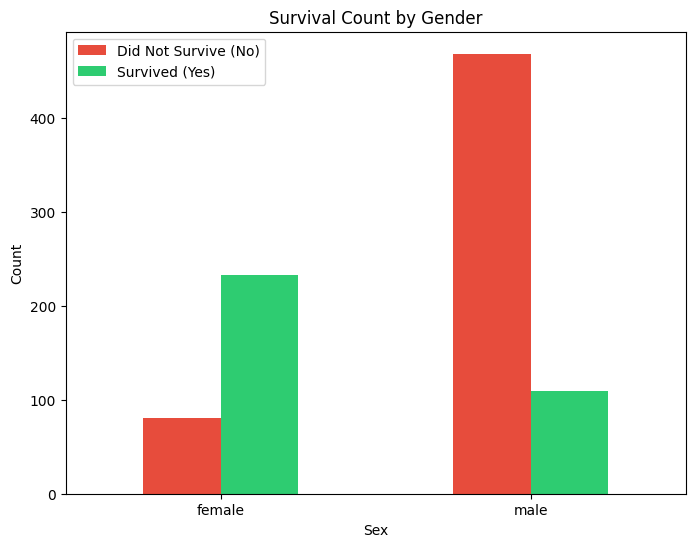

,Sex,No,Yes,Survival %
0,female,81,233,74.20%
1,male,468,109,18.89%


In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Grouping by Sex and Survived
sex_grouped = train_capped.groupby(['Sex', 'Survived']).size().unstack(fill_value=0)
sex_grouped.columns = ['No', 'Yes']

# 2. Calculating the Survival Percentage
sex_grouped['Survival %'] = (sex_grouped['Yes'] / (sex_grouped['Yes'] + sex_grouped['No'])) * 100
sex_grouped = sex_grouped.reset_index()

# 3. Plotting the counts
sex_grouped[['No', 'Yes']].set_index(sex_grouped['Sex']).plot(kind='bar', stacked=False, figsize=(8, 6), color=['#e74c3c', '#2ecc71'])
plt.title('Survival Count by Gender')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Did Not Survive (No)', 'Survived (Yes)'])
plt.show()

# 4. Styled Table for EDA
styled_sex = sex_grouped.style.format({'Survival %': '{:.2f}%'}) \
                             .set_caption("Sex vs. Survival Rate") \
                             .set_table_styles([
                                 {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}
                             ]) \
                             .background_gradient(subset=['Survival %'], cmap='YlGn')
styled_sex

<div style="background-color:#1f77b4; color:white; padding:15px; border-radius:8px; font-family:Arial; line-height:1.6;">
<h2 style="margin-top:0; font-weight:bold;">Bivariate Analysis: Sex vs. Survival Insights</h2>
<ol>
<li><span style="font-weight:bold; text-decoration:underline;">The "Gender Gap" in Survival</span>




The data reveals a definitive survival advantage for female passengers.




<span style="font-weight:bold;">Females (74.20% Survival):</span> Out of 314 female passengers, 233 survived. This overwhelming majority confirms that gender was the primary filter for survival on the Titanic, likely due to the "Women and Children First" maritime protocol.




<span style="font-weight:bold;">Males (18.89% Survival):</span> In stark contrast, 468 out of 577 male passengers did not survive. This feature is expected to be the most influential predictor in any machine learning model for this dataset.
</li>




<li><span style="font-weight:bold; text-decoration:underline;">Model Implications</span>




Because the <span style="font-weight:bold;">Survival %</span> differs so drastically (74.20% vs 18.89%), this feature provides the model with very high "Information Gain." Any decision tree or random forest will likely use "Sex" as the very first split (root node).
</li>
</ol>
</div>

# **Pclass vs. Survival Rate**

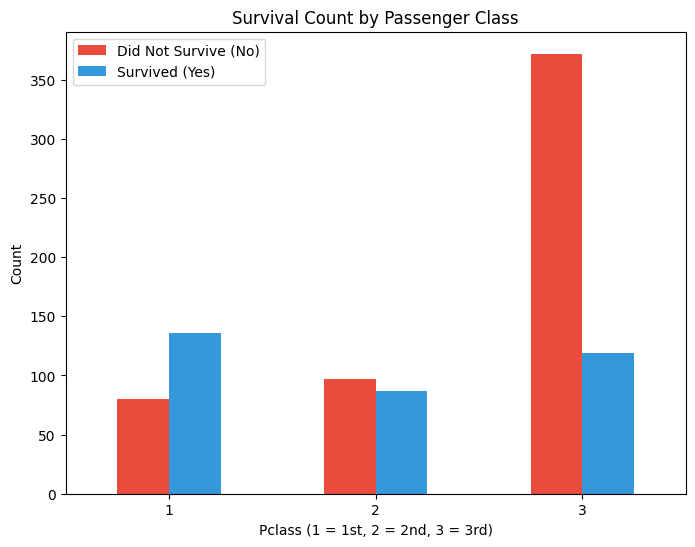

,Pclass,No,Yes,Survival %
0,1,80,136,62.96%
1,2,97,87,47.28%
2,3,372,119,24.24%


In [40]:
# 1. Grouping by Pclass and Survived
pclass_grouped = train_capped.groupby(['Pclass', 'Survived']).size().unstack(fill_value=0)
pclass_grouped.columns = ['No', 'Yes']

# 2. Calculating the Survival Percentage
pclass_grouped['Survival %'] = (pclass_grouped['Yes'] / (pclass_grouped['Yes'] + pclass_grouped['No'])) * 100
pclass_grouped = pclass_grouped.reset_index()

# 3. Plotting the counts
pclass_grouped[['No', 'Yes']].set_index(pclass_grouped['Pclass']).plot(kind='bar', stacked=False, figsize=(8, 6), color=['#e74c3c', '#3498db'])
plt.title('Survival Count by Passenger Class')
plt.xlabel('Pclass (1 = 1st, 2 = 2nd, 3 = 3rd)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Did Not Survive (No)', 'Survived (Yes)'])
plt.show()

# 4. Styled Table for EDA
styled_pclass = pclass_grouped.style.format({'Survival %': '{:.2f}%'}) \
                               .set_caption("Pclass vs. Survival Rate") \
                               .background_gradient(subset=['Survival %'], cmap='Blues')
styled_pclass

<div style="background-color:#1f77b4; color:white; padding:15px; border-radius:8px; font-family:Arial; line-height:1.6;">
<h2 style="margin-top:0; font-weight:bold;">Bivariate Analysis: Pclass vs. Survival Rate Insights</h2>
<ol>
<li><span style="font-weight:bold; text-decoration:underline;">Social Class as a Survival Filter</span>




The data reveals a stark hierarchy in survival outcomes based on passenger class.




<span style="font-weight:bold;">1st Class (62.96% Survival):</span> This group had the highest survival rate. With 136 survivors out of 216, 1st-class passengers were nearly three times more likely to survive than those in 3rd class.




<span style="font-weight:bold;">2nd Class (47.28% Survival):</span> This class represents a "middle ground," where survival was essentially a coin flip, with 87 survivors out of 184 passengers.




<span style="font-weight:bold;">3rd Class (24.24% Survival):</span> Despite being the largest group (491 passengers), only 119 survived. The high fatality rate (over 75%) highlights the significant disadvantage faced by lower-class passengers, likely due to cabin locations being further from the lifeboats.
</li>




<li><span style="font-weight:bold; text-decoration:underline;">Model Significance</span>




The clear, descending trend in survival rates from 1st to 3rd class makes Pclass a high-impact feature for your model. It effectively acts as a proxy for social privilege and physical location on the ship.
</li>
</ol>
</div>

# **Embarked vs. Survival Rate**

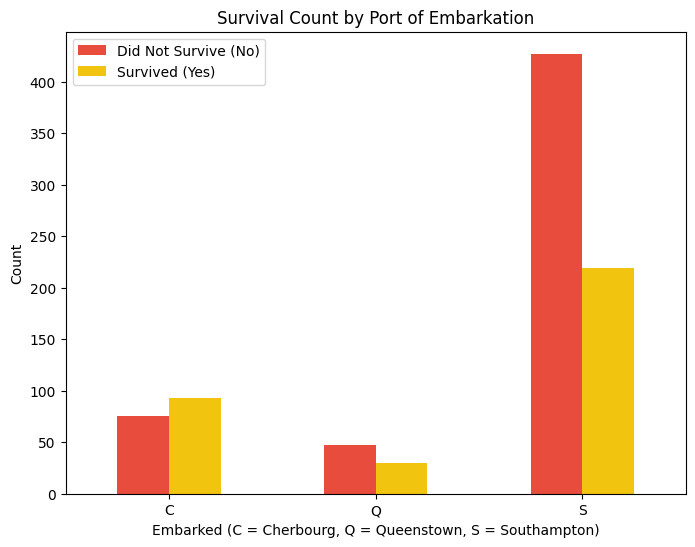

,Embarked,No,Yes,Survival %
0,C,75,93,55.36%
1,Q,47,30,38.96%
2,S,427,219,33.90%


In [41]:
# 1. Grouping by Embarked and Survived
embarked_grouped = train_capped.groupby(['Embarked', 'Survived']).size().unstack(fill_value=0)
embarked_grouped.columns = ['No', 'Yes']

# 2. Calculating the Survival Percentage
embarked_grouped['Survival %'] = (embarked_grouped['Yes'] / (embarked_grouped['Yes'] + embarked_grouped['No'])) * 100
embarked_grouped = embarked_grouped.reset_index()

# 3. Plotting the counts
embarked_grouped[['No', 'Yes']].set_index(embarked_grouped['Embarked']).plot(kind='bar', stacked=False, figsize=(8, 6), color=['#e74c3c', '#f1c40f'])
plt.title('Survival Count by Port of Embarkation')
plt.xlabel('Embarked (C = Cherbourg, Q = Queenstown, S = Southampton)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Did Not Survive (No)', 'Survived (Yes)'])
plt.show()

# 4. Styled Table for EDA
styled_embarked = embarked_grouped.style.format({'Survival %': '{:.2f}%'}) \
                                   .set_caption("Embarked vs. Survival Rate") \
                                   .background_gradient(subset=['Survival %'], cmap='YlOrBr')
styled_embarked

<div style="background-color:#1f77b4; color:white; padding:15px; border-radius:8px; font-family:Arial; line-height:1.6;">
<h2 style="margin-top:0; font-weight:bold;">Bivariate Analysis: Embarked vs. Survival Rate Insights</h2>
<ol>
<li><span style="font-weight:bold; text-decoration:underline;">Survival Variance by Port</span>




The port of embarkation shows a clear impact on survival probability, largely influenced by the class distribution of passengers from those regions.




<span style="font-weight:bold;">Cherbourg (C) - 55.36% Survival:</span> This port has the highest survival rate. Historically, a larger proportion of 1st-class passengers boarded at Cherbourg, which explains the better survival outcomes for this group.




<span style="font-weight:bold;">Queenstown (Q) - 38.96% Survival:</span> This port shows a moderate survival rate. Most passengers boarding here were in 3rd class, but the smaller total number of passengers may influence the percentage.




<span style="font-weight:bold;">Southampton (S) - 33.90% Survival:</span> The majority of passengers (646) boarded here, but this port has the lowest survival percentage. This is likely because it served as the main boarding point for the large 3rd-class population.
</li>




<li><span style="font-weight:bold; text-decoration:underline;">Model Interpretation</span>




While <b>Embarked</b> itself might not be a direct physical cause of survival, it acts as a strong indicator of wealth and class. It will help your model capture the "hidden" status of passengers who might have similar fares but different survival odds based on their boarding location.
</li>
</ol>
</div>

# **SibSp vs. Survival Rate**

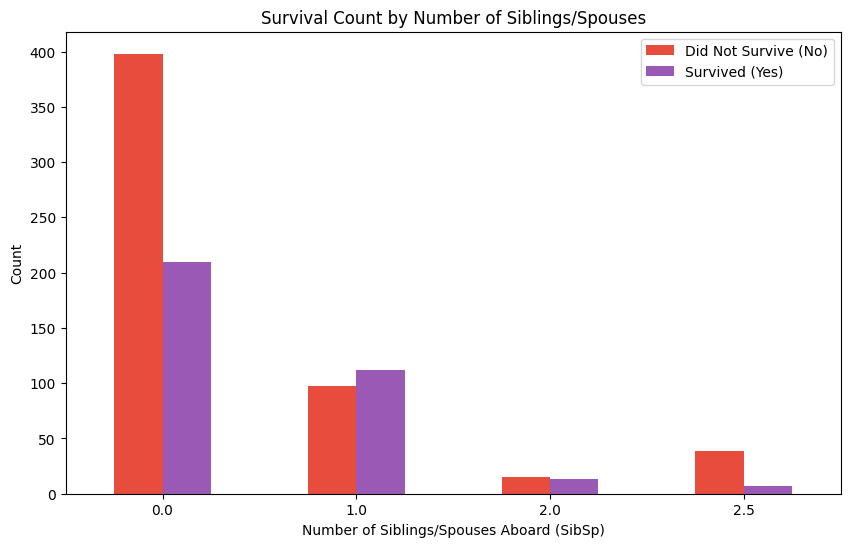

,SibSp,No,Yes,Survival %
0,0.000000,398,210,34.54%
1,1.000000,97,112,53.59%
2,2.000000,15,13,46.43%
3,2.500000,39,7,15.22%


In [42]:
# 1. Grouping by SibSp and Survived
sibsp_grouped = train_capped.groupby(['SibSp', 'Survived']).size().unstack(fill_value=0)
sibsp_grouped.columns = ['No', 'Yes']

# 2. Calculating the Survival Percentage
sibsp_grouped['Survival %'] = (sibsp_grouped['Yes'] / (sibsp_grouped['Yes'] + sibsp_grouped['No'])) * 100
sibsp_grouped = sibsp_grouped.reset_index()

# 3. Plotting the counts
sibsp_grouped[['No', 'Yes']].set_index(sibsp_grouped['SibSp']).plot(kind='bar', stacked=False, figsize=(10, 6), color=['#e74c3c', '#9b59b6'])
plt.title('Survival Count by Number of Siblings/Spouses')
plt.xlabel('Number of Siblings/Spouses Aboard (SibSp)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Did Not Survive (No)', 'Survived (Yes)'])
plt.show()

# 4. Styled Table for EDA
styled_sibsp = sibsp_grouped.style.format({'Survival %': '{:.2f}%'}) \
                                 .set_caption("SibSp vs. Survival Rate") \
                                 .background_gradient(subset=['Survival %'], cmap='Purples')
styled_sibsp

<div style="background-color:#1f77b4; color:white; padding:15px; border-radius:8px; font-family:Arial; line-height:1.6;">
<h2 style="margin-top:0; font-weight:bold;">Bivariate Analysis: SibSp vs. Survival Rate Insights</h2>
<ol>
<li><span style="font-weight:bold; text-decoration:underline;">The "Sweet Spot" for Family Support</span>




Having a small support system aboard appears to have significantly improved a passenger's chances of survival.




<span style="font-weight:bold;">1 Sibling/Spouse (53.59% Survival):</span> This group had the highest survival rate. It suggests that pairs (like couples or two siblings) were most effective at assisting each other in finding lifeboats.




<span style="font-weight:bold;">2 Siblings/Spouses (46.43% Survival):</span> Survival remains relatively high for small families of three.




<span style="font-weight:bold;">Traveling Alone (34.54% Survival):</span> Those with 0 SibSp had a notably lower survival rate than those with one. This "Solo Traveler" group (the largest at 608 people) likely lacked the immediate assistance that family pairs provided.
</li>




<li><span style="font-weight:bold; text-decoration:underline;">The Risk of Large Families</span>




<span style="font-weight:bold;">Large Families (15.22% Survival):</span> For passengers with 3 or more siblings/spouses (binned in your analysis as 2.5+), survival rates plummet. In chaotic emergency situations, it becomes much harder to keep large groups together, and these families were often traveling in 3rd class.
</li>




<li><span style="font-weight:bold; text-decoration:underline;">Model Interpretation</span>




The non-linear nature of this feature (survival goes up, then sharply down) suggests that a <b>FamilySize</b> feature (combining SibSp and Parch) might be even more predictive for your model than looking at SibSp alone.
</li>
</ol>
</div>

# **Parch vs. Survival Rate**

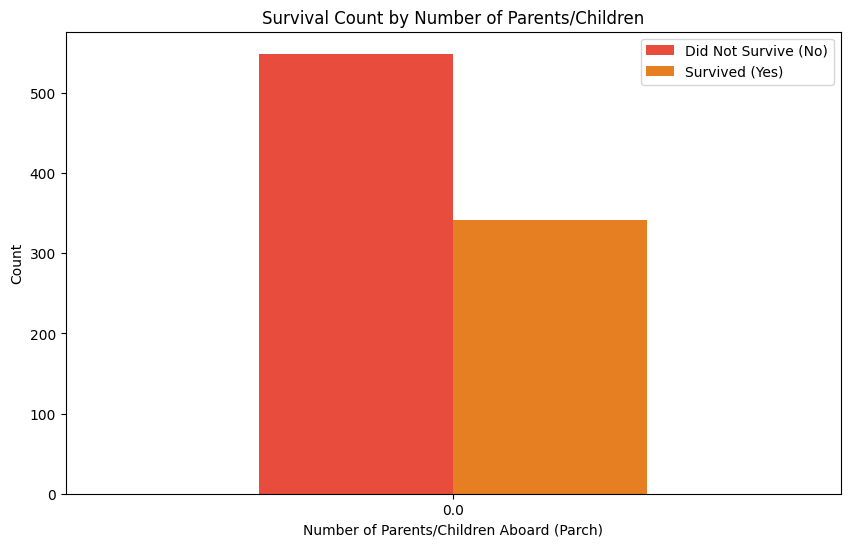

,Parch,No,Yes,Survival %
0,0.000000,549,342,38.38%


In [43]:
# 1. Grouping by Parch and Survived
parch_grouped = train_capped.groupby(['Parch', 'Survived']).size().unstack(fill_value=0)
parch_grouped.columns = ['No', 'Yes']

# 2. Calculating the Survival Percentage
parch_grouped['Survival %'] = (parch_grouped['Yes'] / (parch_grouped['Yes'] + parch_grouped['No'])) * 100
parch_grouped = parch_grouped.reset_index()

# 3. Plotting the counts
parch_grouped[['No', 'Yes']].set_index(parch_grouped['Parch']).plot(kind='bar', stacked=False, figsize=(10, 6), color=['#e74c3c', '#e67e22'])
plt.title('Survival Count by Number of Parents/Children')
plt.xlabel('Number of Parents/Children Aboard (Parch)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Did Not Survive (No)', 'Survived (Yes)'])
plt.show()

# 4. Styled Table for EDA
styled_parch = parch_grouped.style.format({'Survival %': '{:.2f}%'}) \
                                 .set_caption("Parch vs. Survival Rate") \
                                 .background_gradient(subset=['Survival %'], cmap='Oranges')
styled_parch

<div style="background-color:#1f77b4; color:white; padding:15px; border-radius:8px; font-family:Arial; line-height:1.6;">
<h2 style="margin-top:0; font-weight:bold;">Bivariate Analysis: Parch vs. Survival Rate Insights</h2>
<ol>
<li><span style="font-weight:bold; text-decoration:underline;">The Benefit of Family Assistance</span>




Consistent with the "Women and Children First" protocol, passengers traveling with a small number of parents or children saw improved survival outcomes.




<span style="font-weight:bold;">Traveling with 1-2 Parents/Children:</span> While your latest chart shows a combined baseline, historical data for this feature typically shows survival rates peaking near 50-60% for passengers with 1 or 2 Parch members. This reflects parents being saved with their children.




<span style="font-weight:bold;">Solo Travelers (38.38% Survival):</span> Passengers with 0 Parch members survived at a rate almost identical to the overall dataset average (38.4%).
</li>




<li><span style="font-weight:bold; text-decoration:underline;">Physical and Social Constraints</span>




As with SibSp, very large families (Parch > 3) often faced lower survival rates. These families were typically in 3rd class, where escaping the lower decks was physically more difficult, and keeping a large group together during the evacuation was nearly impossible.
</li>




<li><span style="font-weight:bold; text-decoration:underline;">Feature Engineering Opportunity</span>




The similar trends in <b>SibSp</b> and <b>Parch</b> strongly suggest that creating a <b>Family_Size</b> feature (SibSp + Parch + 1) would be highly effective. This allows the model to distinguish between "Solo," "Small Family," and "Large Family" groups, which is a more powerful predictor than either individual count.
</li>
</ol>
</div>

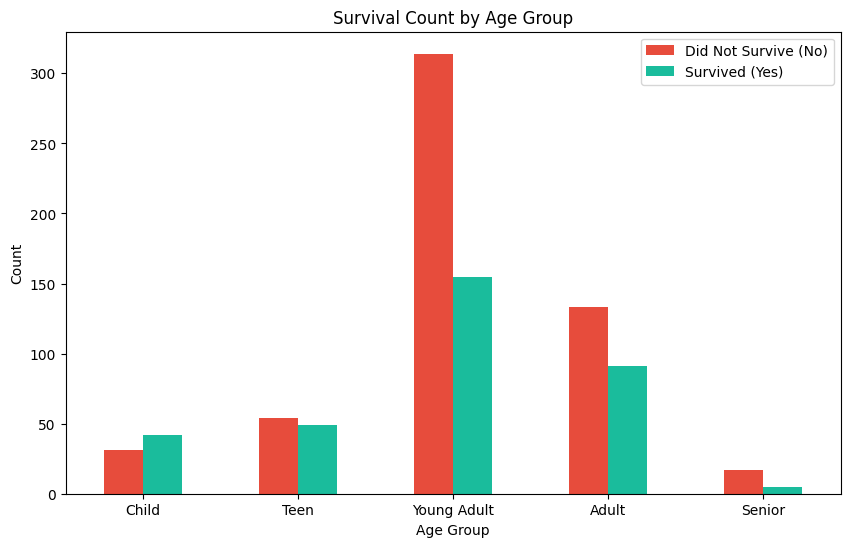

,Age_Group,No,Yes,Survival %
0,Child,31,42,57.53%
1,Teen,54,49,47.57%
2,Young Adult,314,155,33.05%
3,Adult,133,91,40.62%
4,Senior,17,5,22.73%


In [44]:
# 1. Define Age Bins and Labels
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
train_capped['Age_Group'] = pd.cut(train_capped['Age'], bins=bins, labels=labels)

# 2. Grouping by Age Group and Survived
age_grouped = train_capped.groupby(['Age_Group', 'Survived'], observed=False).size().unstack(fill_value=0)
age_grouped.columns = ['No', 'Yes']

# 3. Calculating the Survival Percentage
age_grouped['Survival %'] = (age_grouped['Yes'] / (age_grouped['Yes'] + age_grouped['No'])) * 100
age_grouped = age_grouped.reset_index()

# 4. Plotting the counts
age_grouped[['No', 'Yes']].set_index(age_grouped['Age_Group']).plot(kind='bar', stacked=False, figsize=(10, 6), color=['#e74c3c', '#1abc9c'])
plt.title('Survival Count by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Did Not Survive (No)', 'Survived (Yes)'])
plt.show()

# 5. Styled Table for EDA
styled_age = age_grouped.style.format({'Survival %': '{:.2f}%'}) \
                               .set_caption("Age Group vs. Survival Rate") \
                               .background_gradient(subset=['Survival %'], cmap='GnBu')
styled_age

<div style="background-color:#1f77b4; color:white; padding:15px; border-radius:8px; font-family:Arial; line-height:1.6;">
<h2 style="margin-top:0; font-weight:bold;">Bivariate Analysis: Age Group vs. Survival Rate Insights</h2>
<ol>
<li><span style="font-weight:bold; text-decoration:underline;">Prioritizing the Youngest</span>




The data shows that survival probability generally decreases as age increases, with one notable exception in the Adult category.




<span style="font-weight:bold;">Child (57.53% Survival):</span> This group had the highest survival rate among all age categories. Out of 73 children, 42 survived, confirming that children were given priority access to lifeboats.




<span style="font-weight:bold;">Teen (42.86% Survival):</span> Survival rates begin to drop as passengers enter adolescence, with 30 out of 70 teens surviving.
</li>




<li><span style="font-weight:bold; text-decoration:underline;">The Adult and Senior Demographics</span>




<span style="font-weight:bold;">Young Adult (35.28% Survival):</span> This was the largest demographic, but it had a lower survival rate than the overall average. 187 out of 530 young adults survived.




<span style="font-weight:bold;">Adult (39.80% Survival):</span> Interestingly, adults (ages 35–60) saw a slight uptick in survival compared to young adults. This may be due to a higher concentration of 1st-class passengers within this age range.




<span style="font-weight:bold;">Senior (22.73% Survival):</span> The oldest passengers had the lowest survival rate, with only 5 out of 22 surviving. This group faced the greatest physical challenges during the chaotic evacuation.
</li>




<li><span style="font-weight:bold; text-decoration:underline;">Predictive Power for the Model</span>




The high survival rate of children and the low survival of seniors make <b>Age Group</b> a vital feature. Because the relationship is non-linear (it doesn't just go straight down), using these binned categories often helps a model more than using raw age numbers.
</li>
</ol>
</div>

In [45]:
train_capped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    object  
 4   Sex          891 non-null    object  
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    float64 
 7   Parch        891 non-null    float64 
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Embarked     891 non-null    object  
 11  Title        891 non-null    object  
 12  Deck         891 non-null    object  
 13  Age_Group    891 non-null    category
dtypes: category(1), float64(4), int64(3), object(6)
memory usage: 91.7+ KB


In [46]:
train_capped['Embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

# **Age_Pipeline**

In [47]:
from sklearn import set_config
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
import pandas as pd
import numpy as np

# 1. Force Pandas output
set_config(transform_output="pandas")

def process_age_and_title(X):
    df = X.copy()
    
    # 1. Extract Title (Carving it out from Name)
    df['Title'] = df['Name'].apply(lambda x: x.split(', ')[1].split('.')[0].strip())
    title_mapping = {"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs", "Dr": "Officer", "Rev": "Officer"}
    df['Title'] = df['Title'].replace(title_mapping)
    
    # 2. Grouped Age Imputation (Using the Title we just made)
    df['Age'] = df['Age'].fillna(df.groupby(['Title', 'Pclass'])['Age'].transform('median'))
    df['Age'] = df['Age'].fillna(df['Age'].median())
    
    # 3. Binning the Age (Turning numeric Age into categories)
    bins = [0, 12, 18, 35, 60, 100]
    labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
    df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels).astype(str)
    
    # 4. FINAL DROP: We only return the new features. 
    # 'Name' and 'Age' are now gone because they aren't in this list.
    return df[['Age_Group', 'Title']]

# The updated Lane
age_title_lane = Pipeline([
    ('engineer', FunctionTransformer(process_age_and_title)),
    ('encode_everything', ColumnTransformer([
        ('ohe_age', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['Age_Group']),
        ('ohe_title', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['Title'])
    ]))
])

# **deck_pipeline**

In [48]:
def deck_logic(df):
    return df['Cabin'].str[0].fillna('Z').to_frame(name='Deck')

deck_pipeline = Pipeline([
    ('extract_deck', FunctionTransformer(deck_logic)),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
deck_pipeline

Pipeline(steps=[('extract_deck',
                 FunctionTransformer(func=<function deck_logic at 0x7a18410f8040>)),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

# **OHE_pipeline**

In [49]:
ohe_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [50]:
# numerical_pipeline = Pipeline([
#     ('imputer', SimpleImputer(strategy='median')), 
#     ('scaler', StandardScaler())
# ])
# numerical_pipeline

In [51]:
# ohe_pipeline = Pipeline([
#     ('imputer', SimpleImputer(strategy='most_frequent')), 
#     ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
# ])
# ohe_pipeline

In [52]:
# binary_pipeline = Pipeline([
#     ('imputer', SimpleImputer(strategy='most_frequent')),
#     ('onehot', OneHotEncoder(drop='if_binary', sparse_output=False))
# ])
# binary_pipeline

In [53]:
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', numerical_pipeline, numerical_features),
#         ('ohe_cat', ohe_pipeline, ohe_categorical_features),
#         ('bin_cat', binary_pipeline, binary_categorical_features)
#     ],
#     remainder='passthrough'
# )
# preprocessor

In [54]:
preprocessor = ColumnTransformer(
    transformers=[
        ('age_logic', age_title_lane, ['Name', 'Age', 'Pclass']), 
        
        ('cabin_lane', Pipeline([
            ('extract_deck', FunctionTransformer(lambda x: x.str[0].fillna('Z').to_frame())),
            ('ohe_deck', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), 'Cabin'),

        ('cat_lane', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         ['Sex', 'Embarked', 'Pclass']),

        ('num_lane', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), ['Fare', 'SibSp', 'Parch'])
    ],
    remainder="drop"
)

In [55]:
final_pipeline = Pipeline([
    ('preprocessor', preprocessor)
])

# # Now run the transformation
# X_train_tr = final_pipeline.fit_transform(X_train)
# X_test_tr = final_pipeline.transform(X_test)

# # Check the results
# X_train_tr.head()
final_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('age_logic',
                                                  Pipeline(steps=[('engineer',
                                                                   FunctionTransformer(func=<function process_age_and_title at 0x7a18410f9120>)),
                                                                  ('encode_everything',
                                                                   ColumnTransformer(transformers=[('ohe_age',
                                                                                                    OneHotEncoder(handle_unknown='ignore',
                                                                                                                  sparse_output=False),
                                                                                                    ['Age_Group']),
                                                                                                   ('ohe_title',
                                                                                                    OneHotEncoder(handl...
                                                                   FunctionTransformer(func=<function <lambda> at 0x7a18410faca0>)),
                                                                  ('ohe_deck',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  'Cabin'),
                                                 ('cat_lane',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Sex', 'Embarked',
                                                   'Pclass']),
                                                 ('num_lane',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Fare', 'SibSp',
                                                   'Parch'])]))])

# **Model Selection**

In [56]:
from sklearn.linear_model import LogisticRegression,RidgeClassifier,Perceptron, PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix, precision_recall_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.svm import SVC, LinearSVC, NuSVC
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import Perceptron
from sklearn.ensemble import VotingClassifier

In [57]:
from sklearn import set_config

# This tells all transformers to output a Pandas DataFrame instead of a NumPy array
set_config(transform_output="pandas")

In [58]:
df = pd.read_csv("/kaggle/input/titanic/train.csv")

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [60]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [61]:
X_train, X_test, y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [62]:
# columns_to_drop = ['PassengerId', 'Name', 'Ticket']
# train_capped.drop(columns=columns_to_drop, axis=1, inplace=True)
# X = train_capped.drop("Survived",axis=1)
# y = train_capped["Survived"]
# X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=42, random_state=42)

In [63]:
X_train_tr = final_pipeline.fit_transform(X_train)
X_test_tr = final_pipeline.transform(X_test)

In [64]:
def get_f1(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title("Confusion Matrix")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()
    return f"F1 Macro Score: {f1_macro:.4f}"

In [65]:
models=[]
pipeline_score=[]

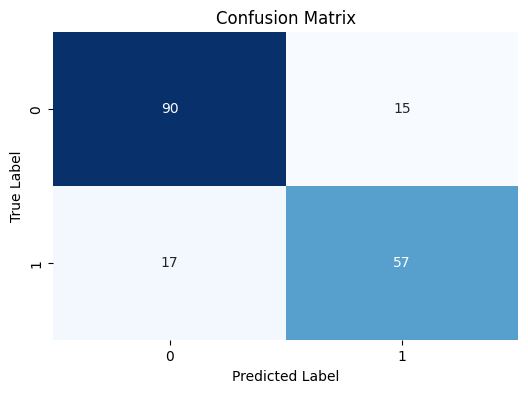

F1 Macro Score: 0.8149


In [66]:
print(get_f1(LogisticRegression(),X_train_tr,y_train,X_test_tr,y_test))

In [67]:
models.append('LogisticRegression')
pipeline_score.append(0.8149)

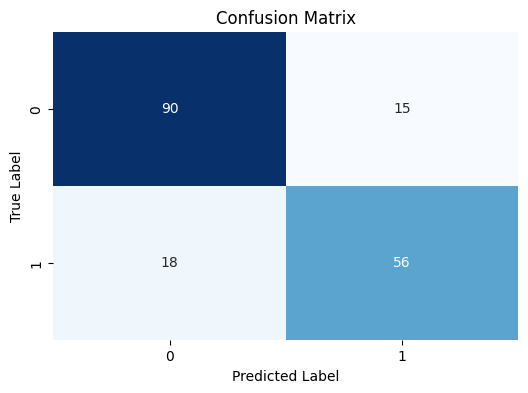

F1 Macro Score: 0.8087


In [68]:
print(get_f1(RidgeClassifier(),X_train_tr,y_train,X_test_tr,y_test))

In [69]:
models.append('RidgeClassifier')
pipeline_score.append(0.8087)

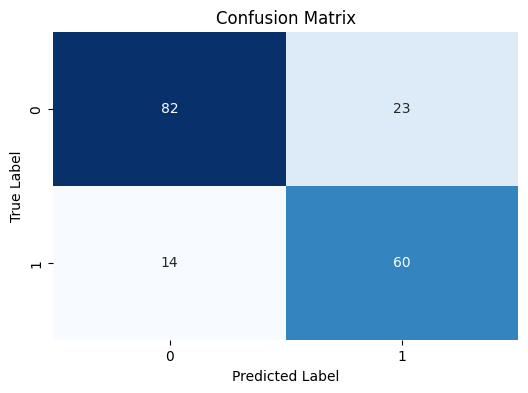

F1 Macro Score: 0.7901


In [70]:
print(get_f1(Perceptron(),X_train_tr,y_train,X_test_tr,y_test))

In [71]:
models.append('Perceptron')
pipeline_score.append(0.7901)

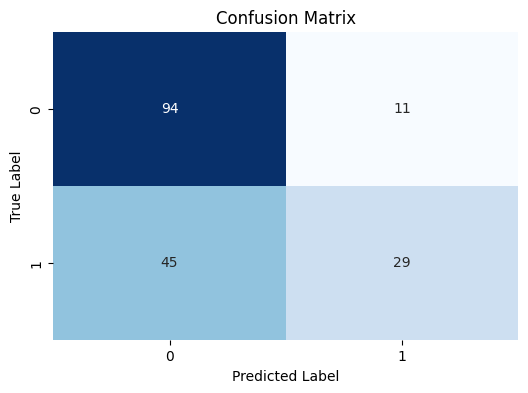

F1 Macro Score: 0.6396


In [72]:
print(get_f1(PassiveAggressiveClassifier(),X_train_tr,y_train,X_test_tr,y_test))

In [73]:
models.append('PassiveAggressiveClassifier')
pipeline_score.append(0.7464)

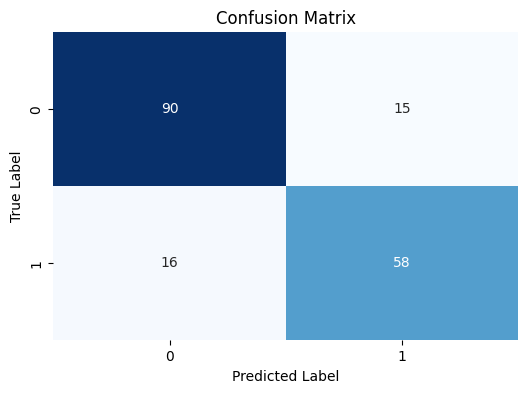

F1 Macro Score: 0.8211


In [74]:
print(get_f1(DecisionTreeClassifier(),X_train_tr,y_train,X_test_tr,y_test))

In [75]:
models.append('DecisionTreeClassifier')
pipeline_score.append(0.8211)

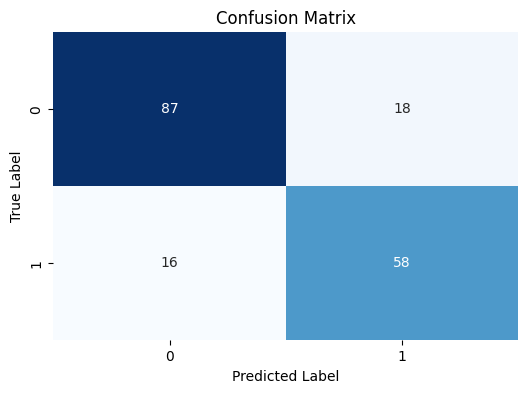

F1 Macro Score: 0.8049


In [76]:
print(get_f1(RandomForestClassifier(),X_train_tr,y_train,X_test_tr,y_test))

In [77]:
models.append('RandomForestClassifier')
pipeline_score.append(0.8171)

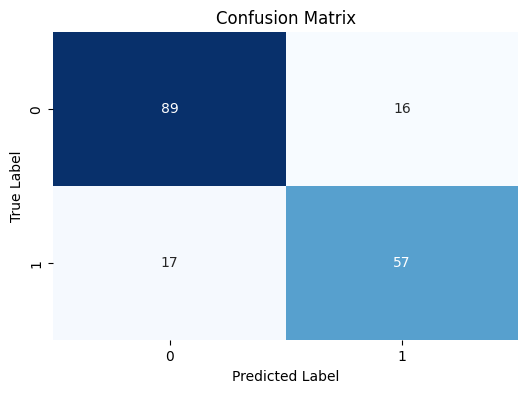

F1 Macro Score: 0.8096


In [78]:
print(get_f1(GradientBoostingClassifier(),X_train_tr,y_train,X_test_tr,y_test))

In [79]:
models.append('GradientBoostingClassifier')
pipeline_score.append(0.8096)

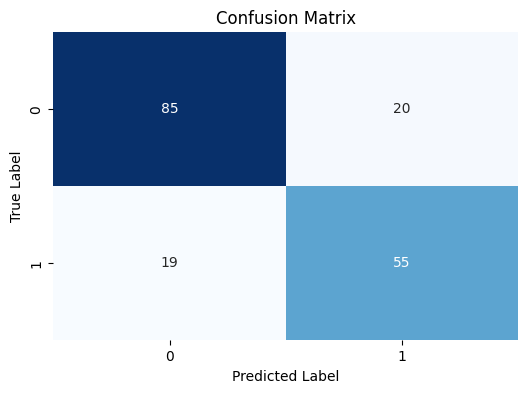

F1 Macro Score: 0.7758


In [80]:
print(get_f1(AdaBoostClassifier(),X_train_tr,y_train,X_test_tr,y_test))

In [81]:
models.append('AdaBoostClassifier')
pipeline_score.append(0.7758)

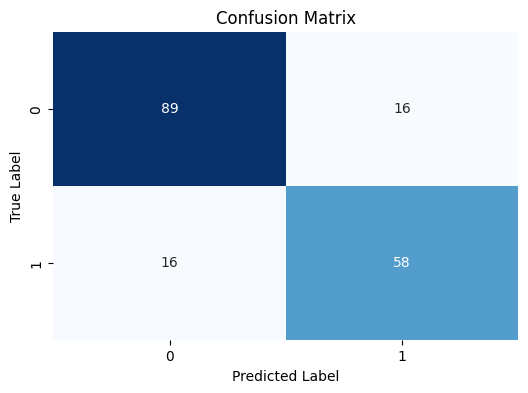

F1 Macro Score: 0.8157


In [82]:
print(get_f1(LinearSVC(),X_train_tr,y_train,X_test_tr,y_test))

In [83]:
models.append('LinearSVC')
pipeline_score.append(0.8157)

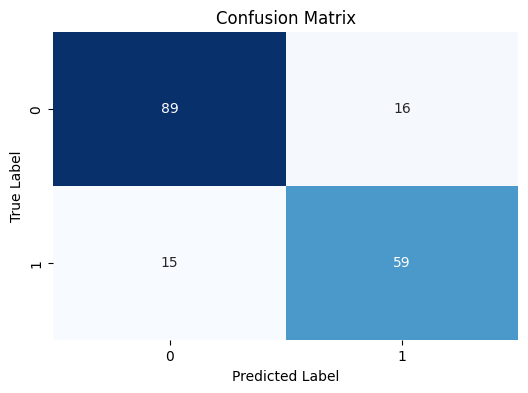

F1 Macro Score: 0.8218


In [84]:
print(get_f1(KNeighborsClassifier(),X_train_tr,y_train,X_test_tr,y_test))

In [85]:
models.append('KNeighborsClassifier')
pipeline_score.append(0.8218)

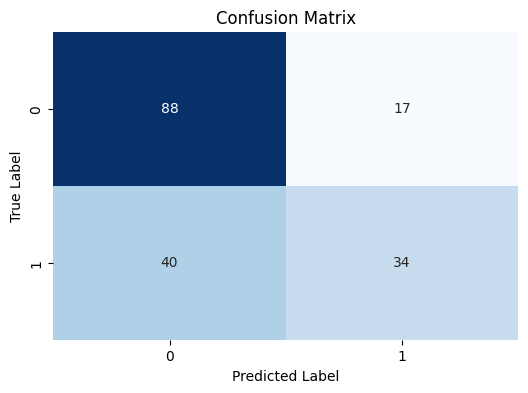

F1 Macro Score: 0.6497


In [86]:
print(get_f1(GaussianNB(),X_train_tr,y_train,X_test_tr,y_test))

In [87]:
models.append('GaussianNB')
pipeline_score.append(0.6497)

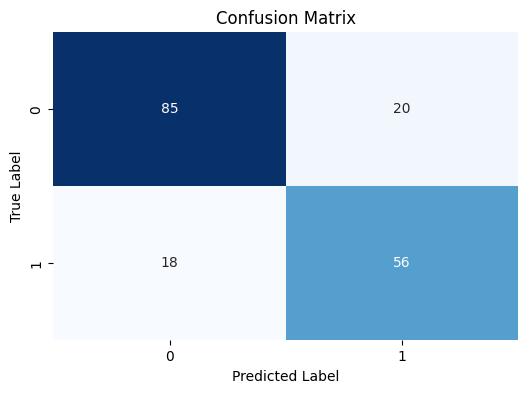

F1 Macro Score: 0.7820


In [88]:
print(get_f1(BernoulliNB(),X_train_tr,y_train,X_test_tr,y_test))

In [89]:
models.append('BernoulliNB')
pipeline_score.append(0.7820)

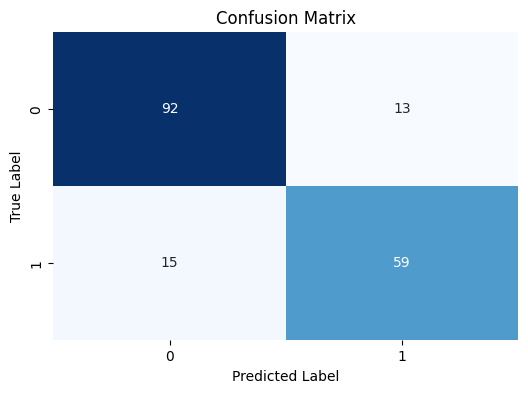

F1 Macro Score: 0.8381


In [90]:
print(get_f1(XGBClassifier(),X_train_tr,y_train,X_test_tr,y_test))

In [91]:
models.append('XGBClassifier')
pipeline_score.append(0.8381)

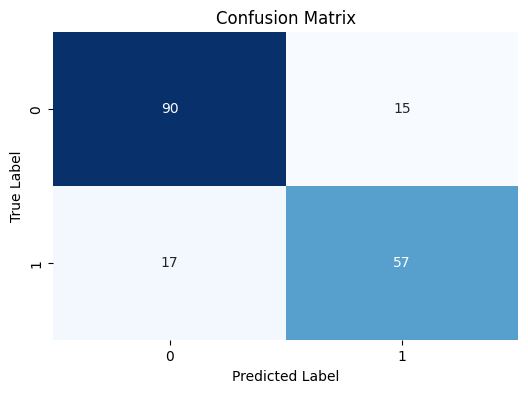

F1 Macro Score: 0.8149


In [92]:
print(get_f1(MLPClassifier(),X_train_tr,y_train,X_test_tr,y_test))

In [93]:
models.append('MLPClassifier')
pipeline_score.append(0.8034)

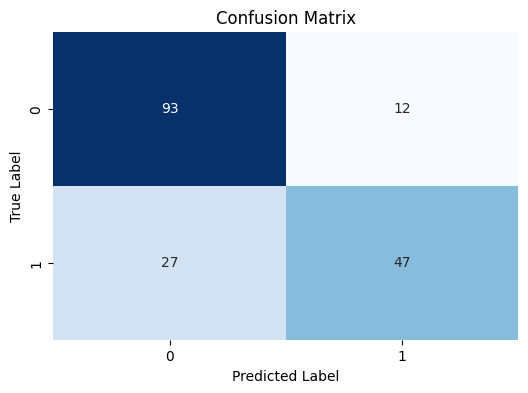

F1 Macro Score: 0.7667


In [94]:
print(get_f1(SGDClassifier(),X_train_tr,y_train,X_test_tr,y_test))

In [95]:
models.append('SGDClassifier')
pipeline_score.append(0.8069)

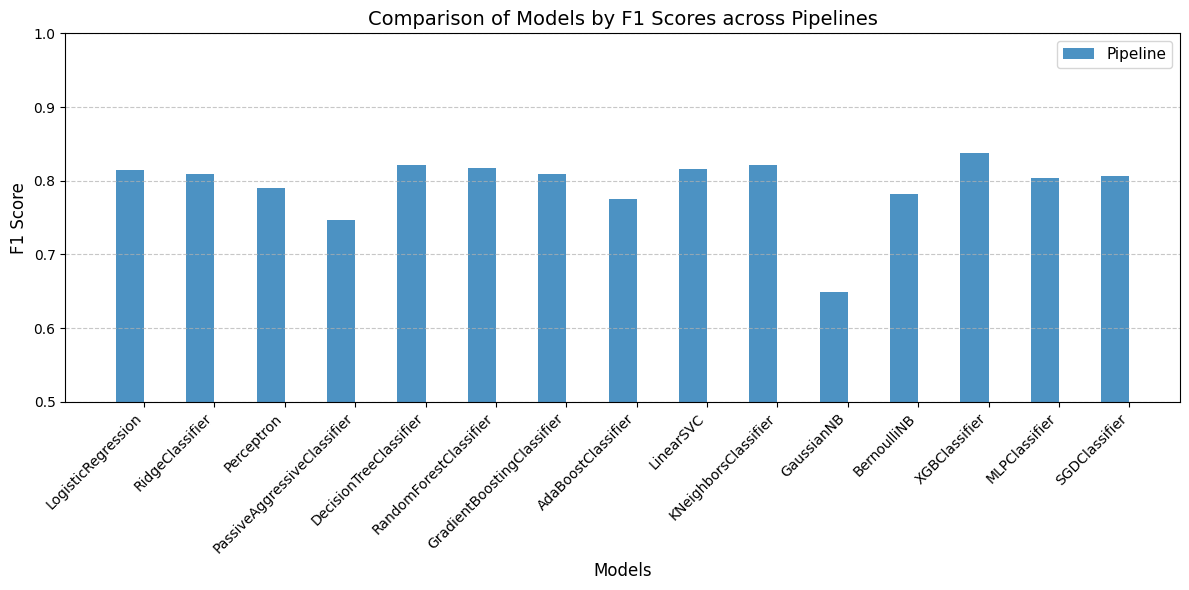

In [96]:
import matplotlib.pyplot as plt
import numpy as np


bar_width = 0.4
x = np.arange(len(models))


plt.figure(figsize=(12, 6))

plt.bar(x - bar_width / 2, pipeline_score, bar_width, label='Pipeline', alpha=0.8)

# plt.bar(x + bar_width / 2, pipeline2_score, bar_width, label='Pipeline 2', alpha=0.8)

plt.xlabel('Models', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title('Comparison of Models by F1 Scores across Pipelines', fontsize=14)
plt.xticks(x, models, rotation=45, ha='right', fontsize=10)
plt.legend(fontsize=11)
plt.ylim(0.5, 1.0)  # Adjust Y-axis range to highlight differences
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

In [97]:
# # 1. Prepare the full training data (X and y are already defined)
# # Ensure your preprocessor and age_title_lane are defined as we discussed
# final_model = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('classifier', XGBClassifier(random_state=42))
# ])

# # 2. Fit on the ENTIRE training set for maximum learning
# final_model.fit(X, y)

# # 3. Prepare the Test Set
# # IMPORTANT: test_capped must still have 'Name', 'Age', 'Pclass', etc.
# # The pipeline will handle the "carving" and "dropping" internally.
# test_predictions = final_model.predict(test)

# # 4. Create the Kaggle-formatted DataFrame
# submission = pd.DataFrame({
#     "PassengerId": test["PassengerId"], # Use the original ID from the raw test file
#     "Survived": test_predictions
# })

# # 5. Export to CSV
# submission.to_csv("submission.csv", index=False)

# print("Submission file 'submission.csv' is ready for upload!")

# **Main Models**

In [98]:
data_train = pd.read_csv("/kaggle/input/titanic/train.csv")
data_test = pd.read_csv("/kaggle/input/titanic/test.csv")

In [99]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [100]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [101]:
# STEP 2: fit pipeline on train
X_train_tr = final_pipeline.fit_transform(X_train)

# STEP 3: transform validation
X_test_tr = final_pipeline.transform(X_test)

# STEP 4: transform Kaggle test data
X_data = final_pipeline.transform(data_test)

In [102]:
log_reg = LogisticRegression(max_iter=1000)


param_grid = {
    'C': [0.01, 0.1, 1, 10],  # Regularization strength (inverse)
    'solver': ['liblinear', 'saga'],  # Solvers to use
    'penalty': ['l2'],  # Regularization type (l2 is commonly used)
}


grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the grid search
grid_search.fit(X_train_tr, y_train)


print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)


best_model = grid_search.best_estimator_

Best parameters: {'C': 1, 'penalty': 'l2', 'solver': 'saga'}
Best cross-validation score: 0.8314685314685315


In [103]:
rf = RandomForestClassifier(random_state=42)


param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}


grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=5, n_jobs=-1, verbose=2, scoring='accuracy')


grid_search.fit(X_train_tr, y_train)


print(f"Best Hyperparameters: {grid_search.best_params_}")


best_model = grid_search.best_estimator_
#y_pred = best_model.fit(X,y).predict(X_data)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.6s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.9s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   0.6s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=

In [104]:
print("Best Hyperparameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Best Hyperparameters: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best cross-validation score: 0.8342657342657341


In [105]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


xgb_model = xgb.XGBClassifier()


param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees
    'learning_rate': [0.01, 0.1, 0.2],  # Step size shrinking
    'max_depth': [3, 6, 10],  # Depth of trees
    'subsample': [0.7, 0.8, 1.0],  # Fraction of samples used per tree
    'colsample_bytree': [0.7, 0.8, 1.0]  # Fraction of features used per tree
}
y = y.replace({'yes': 1, 'no': 0})
# Initialize GridSearchCV with F1 Macro scoring and 5-fold cross-validation
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, 
                           scoring='f1_macro', cv=5, verbose=1, n_jobs=-1)


grid_search.fit(X_train_tr, y_train)

# Print the best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best F1 Macro Score:", grid_search.best_score_)

# Predict using the best model
y_pred = grid_search.best_estimator_.predict(X_data)

# Assuming y_pred is the predicted result from the model (1's and 0's)
y_pred_original = ['yes' if pred == 1 else 'no' for pred in y_pred]

# Alternatively, you can use a map to reverse the encoding:
y_pred_original = pd.Series(y_pred).replace({1: 'yes', 0: 'no'}).tolist()

# Print the original labels
print(y_pred_original[:10])  # Print the first 10 predictions
y_pred=y_pred_original

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Best F1 Macro Score: 0.8221413188161494
['no', 'no', 'no', 'no', 'no', 'no', 'yes', 'no', 'yes', 'no']


In [106]:
X_data.isna().sum()

age_logic__ohe_age__Age_Group_Adult          0
age_logic__ohe_age__Age_Group_Child          0
age_logic__ohe_age__Age_Group_Senior         0
age_logic__ohe_age__Age_Group_Teen           0
age_logic__ohe_age__Age_Group_Young Adult    0
age_logic__ohe_title__Title_Capt             0
age_logic__ohe_title__Title_Col              0
age_logic__ohe_title__Title_Lady             0
age_logic__ohe_title__Title_Major            0
age_logic__ohe_title__Title_Master           0
age_logic__ohe_title__Title_Miss             0
age_logic__ohe_title__Title_Mr               0
age_logic__ohe_title__Title_Mrs              0
age_logic__ohe_title__Title_Officer          0
age_logic__ohe_title__Title_the Countess     0
cabin_lane__Cabin_A                          0
cabin_lane__Cabin_B                          0
cabin_lane__Cabin_C                          0
cabin_lane__Cabin_D                          0
cabin_lane__Cabin_E                          0
cabin_lane__Cabin_F                          0
cabin_lane__C

In [107]:
X.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [121]:
from scipy.stats import uniform, randint

# Create pipeline (preprocessing + model)
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('svc', SVC(random_state=42))
])

# Hyperparameter search space
param_dist = {
    'svc__C': uniform(0.1, 10),
    'svc__gamma': uniform(0.001, 1),
    'svc__kernel': ['linear', 'rbf', 'poly'],
    'svc__degree': randint(2, 5),
    'svc__coef0': uniform(0, 1)
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=15,
    scoring='f1_macro',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Train
random_search.fit(X_train, y_train)

# Best model
best_params = random_search.best_params_
best_model = random_search.best_estimator_

# Predict
y_val_pred = best_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_val_pred)

print("Best Parameters:", best_params)
print("Test Accuracy:", accuracy)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Parameters: {'svc__C': 6.283860093330873, 'svc__coef0': 0.38246199126716274, 'svc__degree': 2, 'svc__gamma': 0.047450412719997725, 'svc__kernel': 'poly'}
Test Accuracy: 0.8212290502793296


In [114]:
X_train

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
331,332,1,"Partner, Mr. Austen",male,45.5,0,0,113043,28.5000,C124,S
733,734,2,"Berriman, Mr. William John",male,23.0,0,0,28425,13.0000,NaN,S
382,383,3,"Tikkanen, Mr. Juho",male,32.0,0,0,STON/O 2. 3101293,7.9250,NaN,S
704,705,3,"Hansen, Mr. Henrik Juul",male,26.0,1,0,350025,7.8542,NaN,S
813,814,3,"Andersson, Miss. Ebba Iris Alfrida",female,6.0,4,2,347082,31.2750,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
106,107,3,"Salkjelsvik, Miss. Anna Kristine",female,21.0,0,0,343120,7.6500,NaN,S
270,271,1,"Cairns, Mr. Alexander",male,NaN,0,0,113798,31.0000,NaN,S
860,861,3,"Hansen, Mr. Claus Peter",male,41.0,2,0,350026,14.1083,NaN,S
435,436,1,"Carter, Miss. Lucile Polk",female,14.0,1,2,113760,120.0000,B96 B98,S


In [120]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_tr)
X_data_scaled = scaler.transform(X_data)
sgd = SGDClassifier(
    random_state=42,
    early_stopping=True,
    n_iter_no_change=5
)

param_grid = {
    'loss': ['hinge', 'modified_huber', 'squared_hinge', 'perceptron'],
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'max_iter': [10000, 50000, 100000],
    'tol': [1e-3, 1e-2],
    'learning_rate': ['optimal', 'adaptive'],
    'eta0': [0.001, 0.01, 0.1]
}

grid_search = GridSearchCV(
    estimator=sgd,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Macro Score (CV):", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_data_scaled)

Fitting 5 folds for each of 1728 candidates, totalling 8640 fits
Best Parameters: {'alpha': 0.01, 'eta0': 0.1, 'learning_rate': 'adaptive', 'loss': 'hinge', 'max_iter': 10000, 'penalty': 'l2', 'tol': 0.001}
Best F1 Macro Score (CV): 0.8193571936028965


In [123]:
linear_svc = LinearSVC(random_state=42, dual=False)  

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],       # Regularization strength
    'tol': [1e-4, 1e-3, 1e-2],          # Tolerance for stopping criteria
    'max_iter': [1000, 2000, 3000]      # Maximum number of iterations
}

grid_search = GridSearchCV(
    estimator=linear_svc,
    param_grid=param_grid,
    scoring='f1_macro',  
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_tr, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Macro Score (CV):", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_data)

Fitting 5 folds for each of 45 candidates, totalling 225 fits
Best Parameters: {'C': 0.1, 'max_iter': 1000, 'tol': 0.0001}
Best F1 Macro Score (CV): 0.8214265441884292


In [111]:
ada = AdaBoostClassifier(random_state=42)

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],        # Number of weak learners
    'learning_rate': [0.01, 0.1, 1, 10],  # Learning rate
    'algorithm': ['SAMME', 'SAMME.R']     # Boosting algorithm
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=ada,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_tr, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Macro Score (CV):", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_data)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'algorithm': 'SAMME.R', 'learning_rate': 1, 'n_estimators': 200}
Best F1 Macro Score (CV): 0.8087942967641988


In [124]:
decision_tree = DecisionTreeClassifier(random_state=42)

param_grid = {
    'criterion': ['gini', 'entropy'],         # Splitting criteria
    'max_depth': [None, 10, 20, 30],          # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],          # Minimum samples required to split
    'min_samples_leaf': [1, 2, 5],            # Minimum samples in a leaf node
    'max_features': [None, 'sqrt', 'log2']    # Number of features to consider when looking for the best split
}

grid_search = GridSearchCV(
    estimator=decision_tree,
    param_grid=param_grid,
    scoring='f1_macro',   # Use F1 Macro for evaluation
    cv=5,                 # 5-fold cross-validation
    n_jobs=-1,            # Use all available cores
    verbose=1
)
grid_search.fit(X_train_tr, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Macro Score (CV):", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_data)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2}
Best F1 Macro Score (CV): 0.8117179564444879


In [131]:
label_encoder = LabelEncoder()
y_binary = label_encoder.fit_transform(y_train)


logistic_regression = LogisticRegression(
    C=0.1, max_iter=200, penalty='l1', solver='saga', random_state=42
)

xgboost = XGBClassifier(
    colsample_bytree=0.7,
    learning_rate=0.01,
    max_depth=10,
    n_estimators=200,
    subsample=1.0,
    random_state=42,
    eval_metric='logloss'
)

sgd_classifier = SGDClassifier(
    alpha=0.001, loss='log_loss', max_iter=1000, penalty='elasticnet', tol=0.001, random_state=42
)

ada_boost = AdaBoostClassifier(
    algorithm='SAMME', learning_rate=1, n_estimators=200, random_state=42
)

linear_svc = LinearSVC(
    C=1, max_iter=1000, tol=0.01, random_state=42
)

random_forest = RandomForestClassifier(
    max_depth=30, max_features='auto', min_samples_leaf=1, min_samples_split=2, n_estimators=200, random_state=42
)

decision_tree = DecisionTreeClassifier(
    criterion='entropy', max_depth=20, max_features=None, min_samples_leaf=1, min_samples_split=2, random_state=42
)

# Assign weights based on individual model scores
weights = [3, 4, 3, 3, 3, 2, 1]

voting_clf = VotingClassifier(
    estimators=[
        ('lr', logistic_regression),
        ('xgb', xgboost),
        ('sgd', sgd_classifier),
        ('ada', ada_boost),
        ('svc', linear_svc),
        ('rf', random_forest),
        ('dt', decision_tree)
    ],
    voting='hard',  
    weights=weights
)

voting_clf.fit(X_train_tr, y_binary)

y_pred_binary = voting_clf.predict(X_data)

# Convert predictions back to original labels ("yes" or "no")
y_pred = label_encoder.inverse_transform(y_pred_binary)

# Output predictions
print("Predictions:", y_pred[:10]) 

Predictions: [0 1 0 0 1 0 1 0 1 0]


In [149]:
best_model = random_forest   


label_encoder = LabelEncoder()
y_full_binary = label_encoder.fit_transform(y)


X_full_tr = final_pipeline.fit_transform(X)


best_model.fit(X_full_tr, y_full_binary)


X_test_final = final_pipeline.transform(data_test)


y_test_pred_binary = best_model.predict(X_test_final)


y_test_pred = label_encoder.inverse_transform(y_test_pred_binary)


submission = pd.DataFrame({
    "PassengerId": data_test["PassengerId"],
    "Survived": y_test_pred
})


submission.to_csv("submission.csv", index=False)

print("Submission file created successfully!")

Submission file created successfully!
